In [2]:
import sys

project_path = '/content/drive/MyDrive/credit_score_project'

if project_path not in sys.path:
    sys.path.append(project_path)

In [3]:
import kagglehub
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import my_module.custom_transformers as cst
import joblib
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer

sklearn.set_config(transform_output = 'pandas')
pd.set_option('display.max_columns',None)

In [ ]:
gmsc_dataset_raw =pd.read_csv('/content/drive/MyDrive/credit_score_project/datasets_cleaned/gmsc_cleaned.csv',index_col='Unnamed: 0')
gmsc_df = gmsc_dataset_raw.copy()

In [ ]:
gmsc_df.head()


,defaults,RUUL,age,30-59 passed,DebtRatio,MonthlyIncome,open credits,90 passed,Real Estate credits,60-89 passed,dependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
gmsc_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145838 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   defaults             145838 non-null  int64  
 1   RUUL                 145838 non-null  float64
 2   age                  145838 non-null  int64  
 3   30-59 passed         145838 non-null  int64  
 4   DebtRatio            145838 non-null  float64
 5   MonthlyIncome        120121 non-null  float64
 6   open credits         145838 non-null  int64  
 7   90 passed            145838 non-null  int64  
 8   Real Estate credits  145838 non-null  int64  
 9   60-89 passed         145838 non-null  int64  
 10  dependents           145838 non-null  float64
dtypes: float64(4), int64(7)
memory usage: 13.4 MB


In [ ]:
gmsc_df.describe()

,defaults,RUUL,age,30-59 passed,DebtRatio,MonthlyIncome,open credits,90 passed,Real Estate credits,60-89 passed,dependents
count,0,0,0,0,0,0,0,0,0,0,0
unique,0,0,0,0,0,0,0,0,0,0,0
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
target_col = ['defaults']
num_cols = ['age','MonthlyIncome','DebtRatio','open credits','dependents','RUUL','Real Estate credits','90 passed','60-89 passed','30-59 passed']

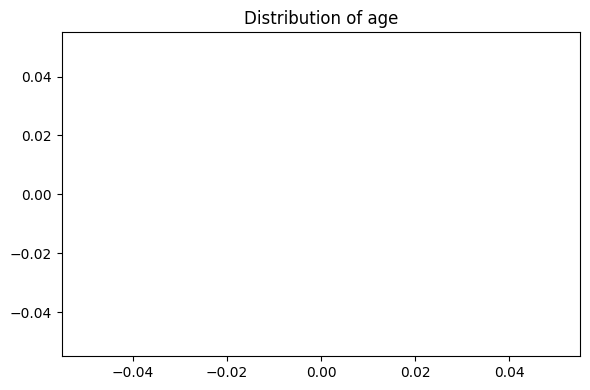

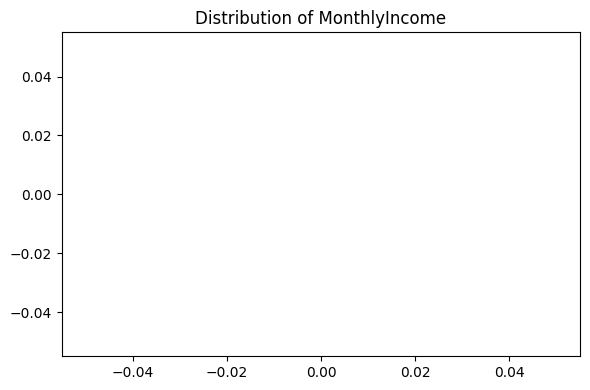

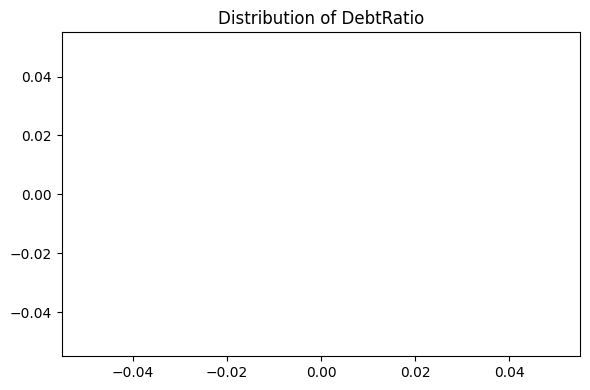

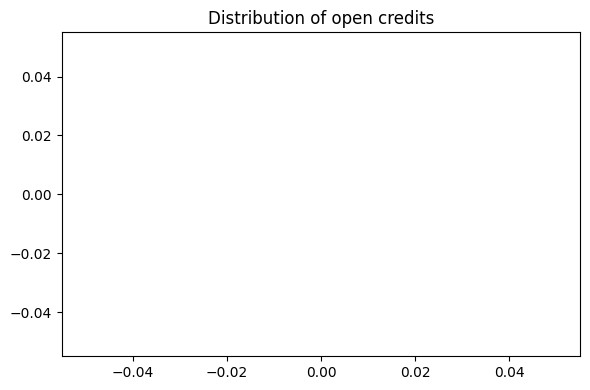

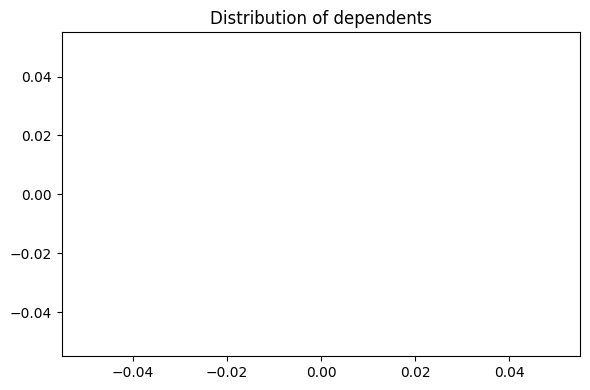

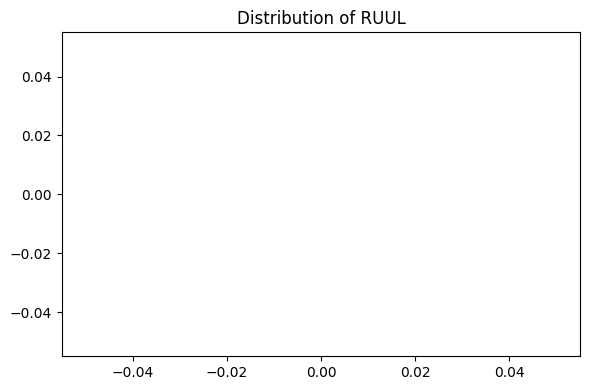

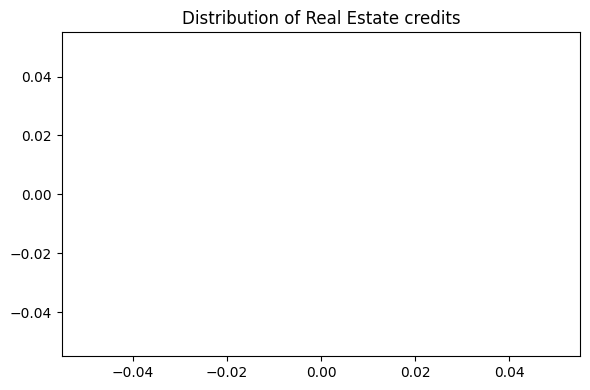

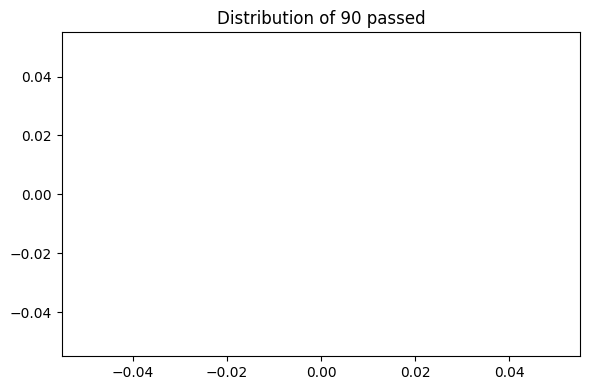

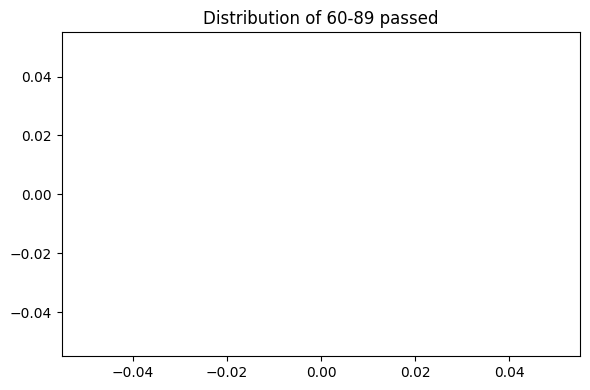

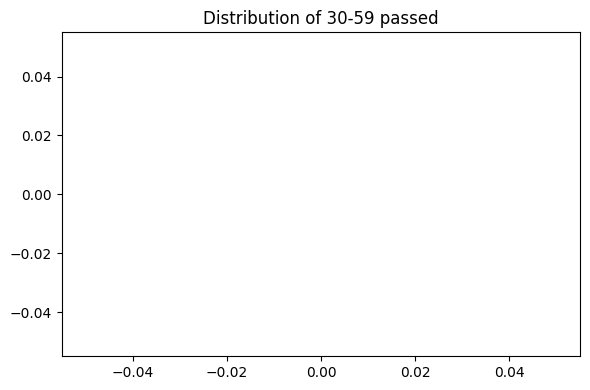

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(gmsc_df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()
# From the distribution it can be seen that we need to handle some
# outliers perheps.

/tmp/ipython-input-3423374153.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='defaults')


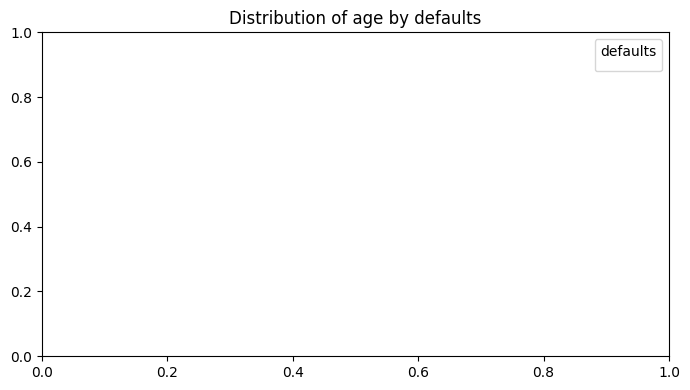

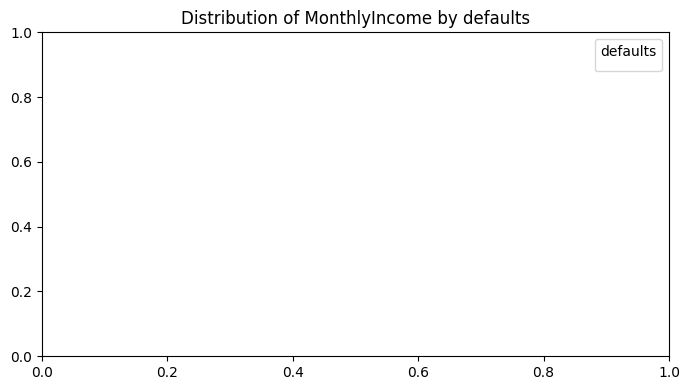

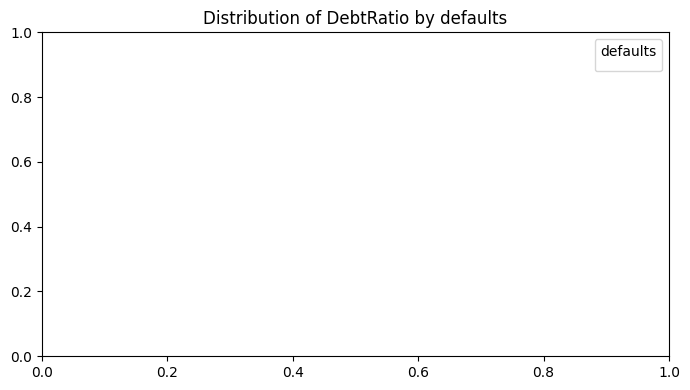

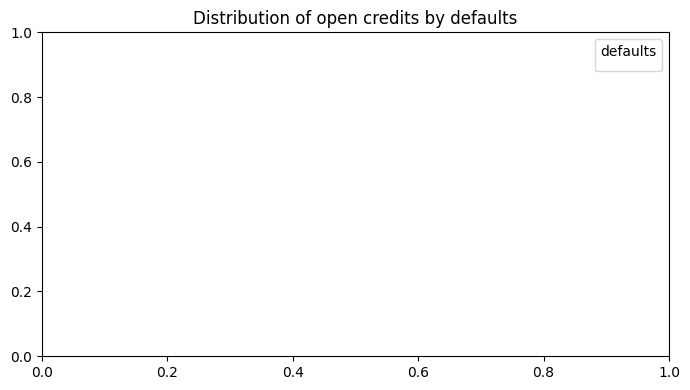

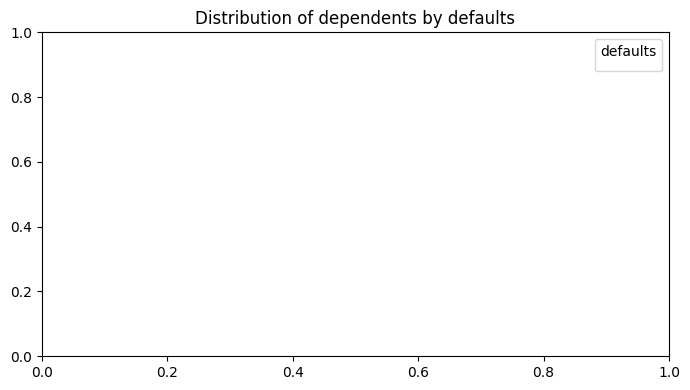

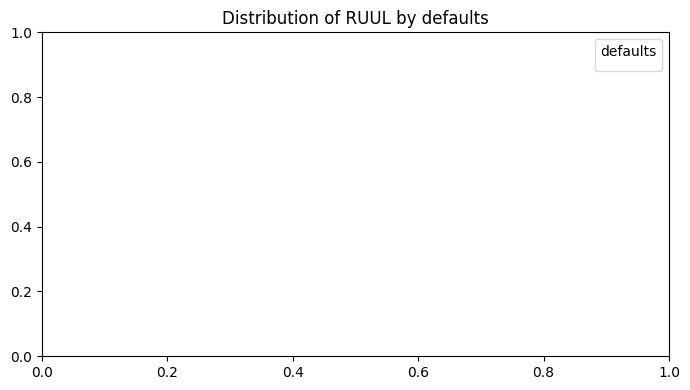

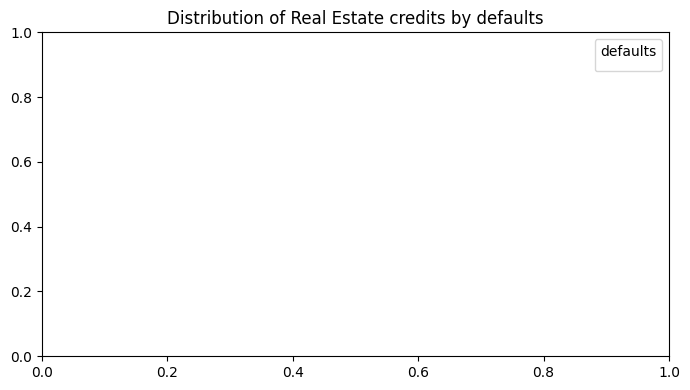

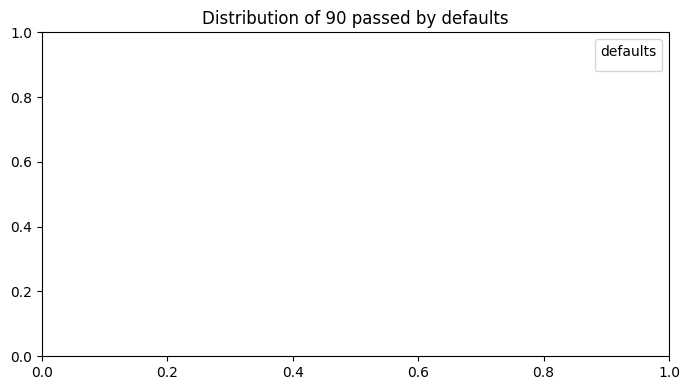

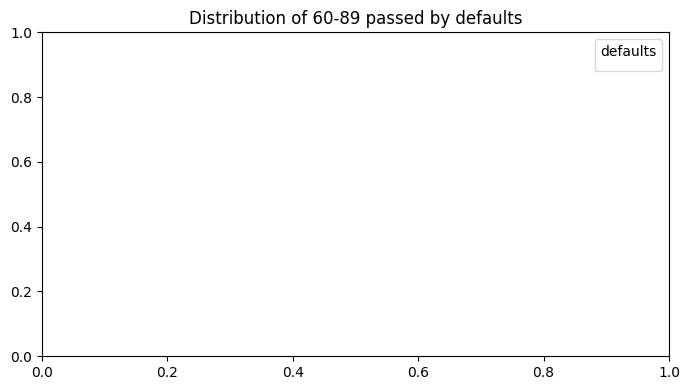

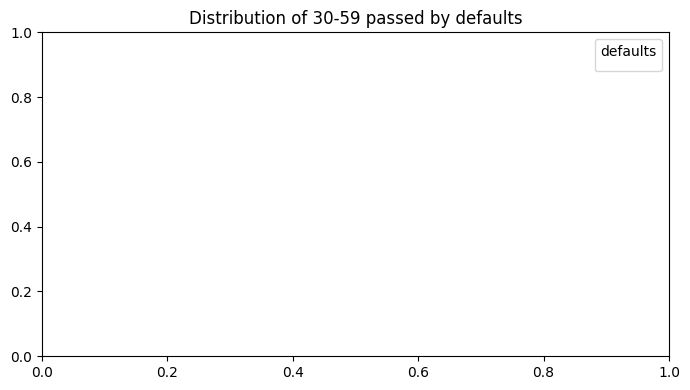

In [ ]:
for col in num_cols:
    plt.figure(figsize=(7,4))

    for score in gmsc_df['defaults'].unique():
        subset = gmsc_df[gmsc_df['defaults'] == score]
        sns.kdeplot(subset[col], label=score, fill=True, alpha=0.3)

    plt.title(f'Distribution of {col} by defaults')
    plt.legend(title='defaults')
    plt.tight_layout()
    plt.show()
## From the distributions there are no actionable observations

In [ ]:
corr_matrix = gmsc_df[num_cols].corr(method='pearson')

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=False,
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.title("Correlation Matrix (Numerical Features)")
plt.tight_layout()
plt.show()

In [ ]:
X = gmsc_df[num_cols].copy()
X = X.fillna(X.median())

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data.sort_values(by="VIF", ascending=False)


In [ ]:
gmsc_df['defaults'].sum()/gmsc_df.shape[0]

In [ ]:
X = gmsc_df.drop(columns=target_col)
y = gmsc_df[target_col]

X_train,X_Test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42,stratify=y)

print(y_train.sum()/y_train.shape[0])
print(y_test.sum()/y_test.shape[0])

# From the cleaned dataset it looks like we do not need to do any
# encdoing, but imputation and outlier detection will be required.
# For that we also need to understand the relationship of outliers
# and nan with target variable.

defaults    0.066598
dtype: float64
defaults    0.06658
dtype: float64


In [ ]:
print(gmsc_df.loc[gmsc_df['MonthlyIncome'].isnull(),target_col].value_counts())

print(gmsc_df.loc[~gmsc_df['MonthlyIncome'].isnull(),target_col].value_counts())

# It is different but not a significant difference between ratios
# ~20% of values are missing

num_describe = pd.DataFrame()
for col in num_cols:
  if col != 'MonthlyIncome':
    num_describe[f'{col}_N'] = X_train.loc[X_train['MonthlyIncome'].isnull(),col].describe()
    num_describe[col] = X_train.loc[~X_train['MonthlyIncome'].isnull(),col].describe()
num_describe

# We can clearlyl define the monthlyIncome nan relation with debtratio.
# Though other relation are there but not so much obvious ones
# Debtratio also includes outlier and I am not sure how the debtratio has beed
# calculated here but MonthlyIncome might be used as denominator here.
# missingness ~ 20% but here we can not use knn imputaion reason being scalling,
# outliers. and although we have seen the ration of defaults vs missingness there might
# be case that it implies something. So I am going to add column stating the value is
# missing. at this time this approach look better to me.

,age_N,age,DebtRatio_N,DebtRatio,open credits_N,open credits,dependents_N,dependents,RUUL_N,RUUL,Real Estate credits_N,Real Estate credits,90 passed_N,90 passed,60-89 passed_N,60-89 passed,30-59 passed_N,30-59 passed
count,20584.000000,96086.000000,20584.000000,96086.000000,20584.000000,96086.000000,20584.000000,96086.000000,20584.000000,96086.000000,20584.000000,96086.000000,20584.000000,96086.000000,20584.000000,96086.000000,20584.000000,96086.000000
mean,55.931549,51.307704,1765.557132,26.146093,7.489409,8.765460,0.317771,0.853194,6.083535,6.350360,0.916926,1.054992,0.091770,0.090617,0.058103,0.066274,0.190148,0.260173
std,14.806446,14.398993,4024.276706,397.565670,4.887242,5.152614,0.811676,1.148409,226.400760,277.760980,1.037600,1.137227,0.492259,0.481321,0.308939,0.332237,0.616687,0.716918
min,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,45.000000,41.000000,216.750000,0.144871,4.000000,5.000000,0.000000,0.000000,0.017585,0.035007,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,51.000000,1296.000000,0.296489,7.000000,8.000000,0.000000,0.000000,0.087999,0.176886,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,66.000000,61.000000,2491.000000,0.482619,10.000000,11.000000,0.000000,2.000000,0.456705,0.577750,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,107.000000,103.000000,326442.000000,60212.000000,45.000000,57.000000,8.000000,13.000000,22198.000000,50708.000000,23.000000,32.000000,11.000000,15.000000,7.000000,11.000000,10.000000,13.000000


In [ ]:
col = 'dependents'
Q1 = X_train[col].quantile(0.25)
Q3 = X_train[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = X_train_imputed[(X_train[col]>upper) | (X_train[col]<lower)]
outliers.shape

# For debt ratio
# upper = outliers[(outliers['MonthlyIncome']!= 5400) & (outliers['MonthlyIncome']>2)].sort_values(by='MonthlyIncome').max()
# In the case of open and real estate credits outliers values have higher monthly income so no actions taken
upper_debt = 273
upper_ruul = X_train_imputed['RUUL'].quantile(0.99)
X_train_imputed['RUUL'] = X_train_imputed['RUUL'].clip(upper=upper_ruul)
X_train_imputed['DebtRatio'] = X_train_imputed['DebtRatio'].clip(upper=upper_debt)

(10717, 11)

In [ ]:
X_train_imputed = imputer.fit_transform(X_train)
X_train_cleaned = winsoriser.fit_transform(X_train_imputed)

In [ ]:
X_train_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 116670 entries, 74292 to 46702
Data columns (total 11 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   RUUL                            116670 non-null  float64
 1   age                             116670 non-null  float64
 2   30-59 passed                    116670 non-null  float64
 3   DebtRatio                       116670 non-null  float64
 4   MonthlyIncome                   116670 non-null  float64
 5   open credits                    116670 non-null  float64
 6   90 passed                       116670 non-null  float64
 7   Real Estate credits             116670 non-null  float64
 8   60-89 passed                    116670 non-null  float64
 9   dependents                      116670 non-null  float64
 10  missingindicator_MonthlyIncome  116670 non-null  float64
dtypes: float64(11)
memory usage: 10.7 MB


In [ ]:
skewed_cols = ['RUUL','MonthlyIncome','DebtRatio']
std_cols = ['age','Real Estate credits','open credits','90 passed','30-59 passed','60-89 passed']
log_transformed = np.log1p(X_train_cleaned[skewed_cols])
std_scaler = StandardScaler()
std_scaled_data = std_scaler.fit_transform(log_transformed)

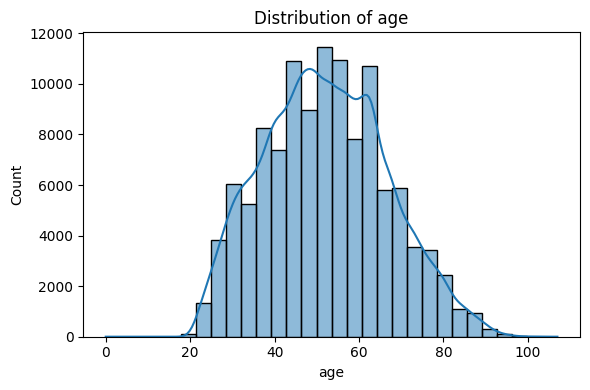

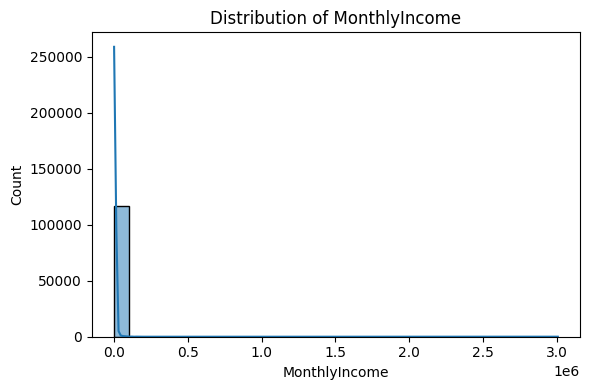

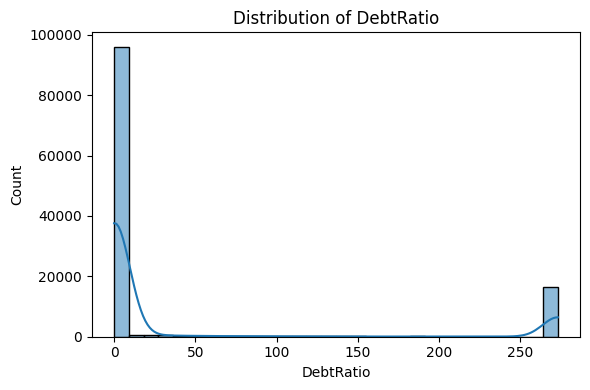

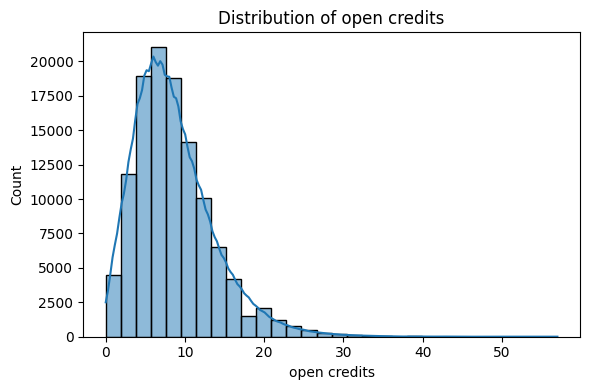

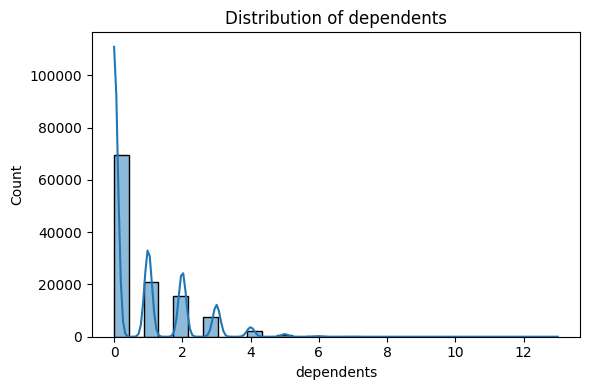

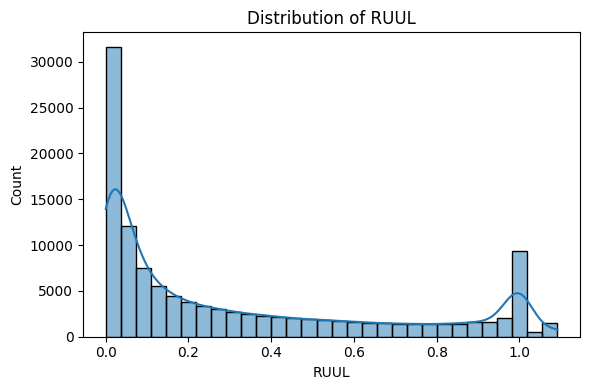

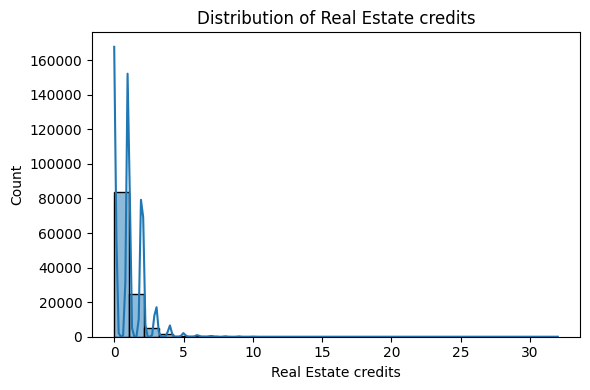

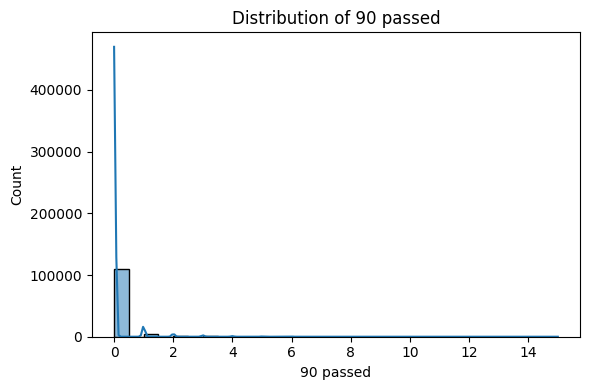

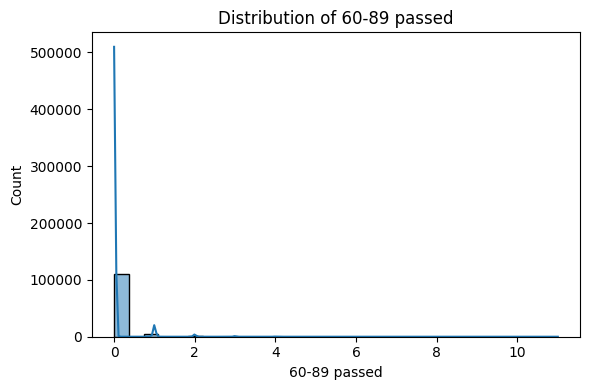

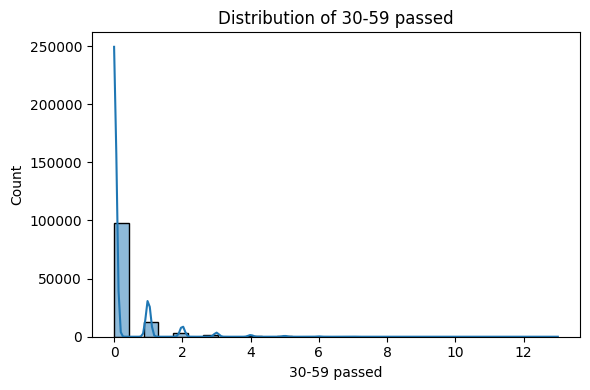

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(X_train_cleaned[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()
# Except age every col in rightly skewed almost

In [4]:
from types import NoneType


from sklearn import set_config
set_config(transform_output="pandas")

pipe_log = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, validate=False)),
    ('scaler', StandardScaler())
])

pipe_scale = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

pipe_binary = 'passthrough'

columntransformer_scale = ColumnTransformer([

    ('log_cols', pipe_log,
     ['MonthlyIncome','DebtRatio']),

    ('scaled_cols', pipe_scale,
     ['RUUL','open credits','Real Estate credits',
      '90 passed','30-59 passed','60-89 passed','age']),

    ('binary_cols', pipe_binary,
     ['MonthlyIncome_missing'])
])

preprocess_pipeline = Pipeline([
    ('add_missing_flag', cst.AddMissingFlag(column='MonthlyIncome')),
    ('outlier', cst.gmsc_outlier_handle(columns=['RUUL','DebtRatio'])),
    ('preprocess', columntransformer_scale),
    ('renamer',cst.renamer())
])

In [5]:
preprocess_pipeline
# import joblib
# joblib.dump(preprocess_pipeline,'/content/drive/MyDrive/credit_score_project/preprocessing/gmsc_preprocess_v1.joblib')

Pipeline(steps=[('add_missing_flag', AddMissingFlag(column='MonthlyIncome')),
                ('outlier', gmsc_outlier_handle(columns=['RUUL', 'DebtRatio'])),
                ('preprocess',
                 ColumnTransformer(transformers=[('log_cols',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyIncome',
                                                   'DebtRatio']),
                                                 ('scaled_cols',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['RUUL', 'open credits',
                                                   'Real Estate credits',
                                                   '90 passed', '30-59 passed',
                                                   '60-89 passed', 'age']),
                                                 ('binary_cols', 'passthrough',
                                                  ['MonthlyIncome_missing'])])),
                ('renamer', renamer())])

In [ ]:
# pipe_processed = preprocess_pipeline.fit_transform(X_train)